In [27]:
import os
import sys
import scanpy as sc
import scvelo as scv

In [28]:
# r-reticulate env
adata = sc.read("path/Bmp4_YS_D6_velocyto.h5ad")

In [29]:
adata

AnnData object with n_obs × n_vars = 8380 × 27622
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent_mt', 'RNA_snn_res_2', 'seurat_clusters', 'cell_types', 'cell_types_ordered', 'update_celltypes', 'update_celltypes_ordered', 'cell_annotation_abbre', 'nCount_spliced', 'nFeature_spliced', 'nCount_unspliced', 'nFeature_unspliced'
    var: 'vst_mean', 'vst_variance', 'vst_variance_expected', 'vst_variance_standardized', 'vst_variable', 'highly_variable_genes'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    layers: 'spliced', 'unspliced'

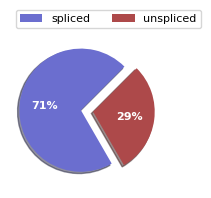

Normalized count data: X, spliced, unspliced.
computing neighbors
    finished (0:00:01) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:28) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:22) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/16 cores)



    finished (0:01:49) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:02) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


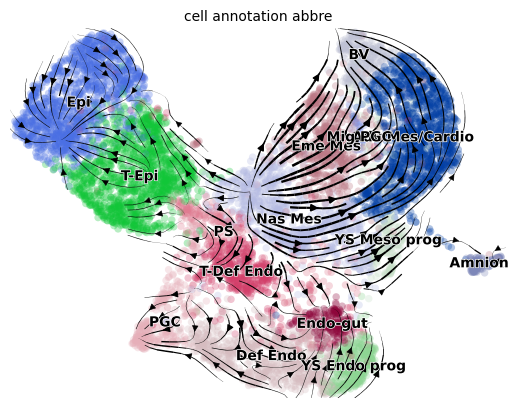

In [30]:
scv.pl.proportions(adata)
scv.pp.moments(adata, n_pcs=30, n_neighbors=30) # if there is no PCA, please run PCA at first.
scv.tl.velocity(adata)
scv.tl.velocity_graph(adata) # Also other models could be used.
scv.pl.velocity_embedding_stream(adata, basis='umap', color = 'cell_annotation_abbre')

In [31]:
import pandas as pd
current_categories = adata.obs['cell_annotation_abbre'].cat.categories

# 定义你想要的顺序
desired_order = ["Epi","T-Epi","PS","Nas Mes",
                     "Eme Mes","Adv Mes/Cardio",
                     "BV","T-Def Endo",
                     "Def Endo","Endo-gut",
                     "YS Meso prog","YS Endo prog",
                     "Amnion","PGC","Mig PGC"]

# 确保所有类别都在新顺序中
assert set(current_categories) == set(desired_order), "类别不匹配"

# 重新排序类别
adata.obs['cell_type_order'] = pd.Categorical(
    adata.obs['cell_annotation_abbre'],
    categories=desired_order,
    ordered=True
)

In [32]:
color_dict = {"Epi":"#D48F5A","T-Epi":"#768822","PS":"#E9BEC9","Nas Mes":"#BD4E21",
                             "Eme Mes":"#AF5092","Adv Mes/Cardio":"#F1EDAC",
                             "BV":"#0094BE","T-Def Endo":"#3B9700",
                             "Def Endo":"#C23B2E","Endo-gut":"#D3949F",
                             "YS Meso prog":"#969696",
                             "YS Endo prog":"#DF873E",
                             "Amnion":"#9E342D","PGC":"#7C6473","Mig PGC":"#AE7360"}

In [33]:
categories = adata.obs['cell_type_order'].cat.categories
palette = [color_dict[cat] for cat in categories]

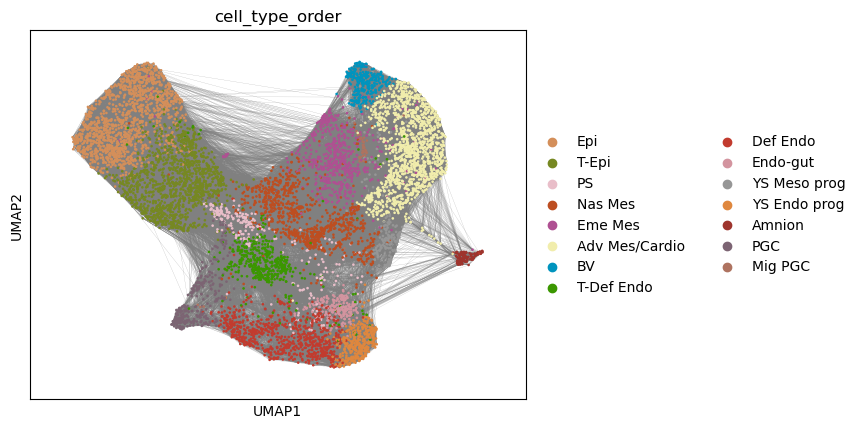

In [34]:
sc.pl.umap(
    adata, 
    color='cell_type_order',palette=palette, edges=True)

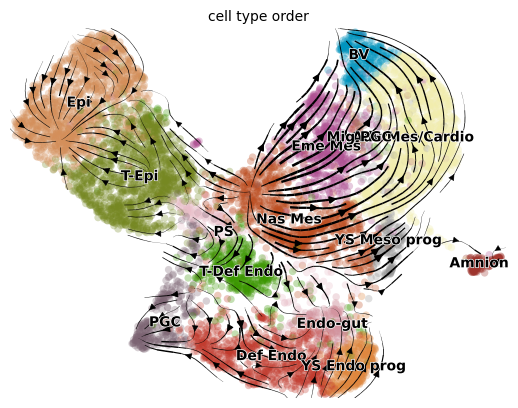

In [35]:
scv.pl.velocity_embedding_stream(adata, basis='umap', color = 'cell_type_order',palette=palette)

figure cannot be saved as pdf, using png instead.
saving figure to file ./figures/scvelo_BMP4_YS_D6_velocity.png


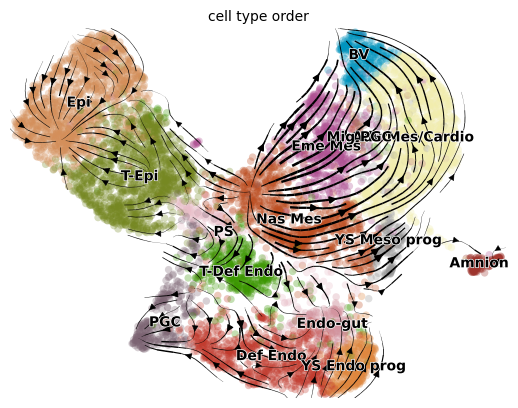

In [36]:
scv.pl.velocity_embedding_stream(adata, basis='umap', color = 'cell_type_order',palette=palette,save='BMP4_YS_D6_velocity.pdf')

In [37]:
cluster_mask = adata.obs['cell_annotation_abbre'].isin(["Def Endo","Endo-gut","YS Endo prog"])
adata_subset = adata[cluster_mask, :].copy()

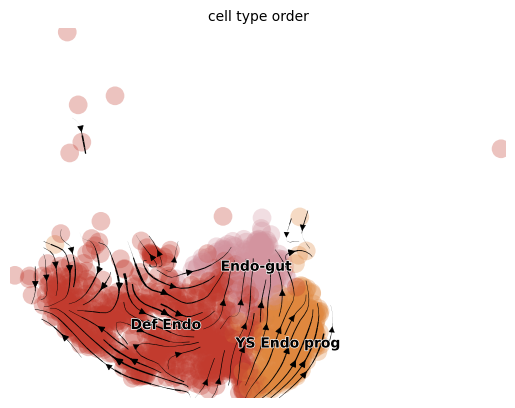

In [38]:
scv.pl.velocity_embedding_stream(adata_subset, basis='umap', color = 'cell_type_order')